# Analysis of the Rotator Vibration

This notebook is to analyze the rotator vibration happend in the top-end assembly (TEA) or the soak test.
The target is to find a way to detect the TEA vibration reliablily.

## Summary

Observation:

1. When the rotator is stalled, the characteristic peak is around 0.1 Hz.
2. When the rotator is stalled and there is the TEA vibration, the characteristic peak is around 0.54 Hz.
3. When the rotator is slewing and tracking, there are peaks in the range between 0 Hz and 1 Hz as the low-frequency vibration.

Proposal:

The rotator CSC sents the low-frequency vibration event only when there are the "n-times" continuous low-frequency vibration.
This "n-times" and other parameters needed in the detection algorithm can be changed in the configuration file.
This event might not be able to decide the TEA vibration by itself only.
Other information from other components would be needed to judge the TEA is vibrating or not.

## Import Modules

In [1]:
%matplotlib inline
%matplotlib widget
from datetime import datetime
import time
from astropy.time import Time
import pandas as pd
from pandas.core.frame import DataFrame
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import detrend

from lsst_efd_client import EfdClient

## Declaration of User-defined Functions

In [2]:
async def get_efd_data(
    efd_client: EfdClient,
    time_start: Time,
    time_end: Time,
) -> DataFrame:
    """Get the EFD data.

    Parameters
    ----------
    efd_client : `lsst_efd_client.EfdClient`
        EFD client.
    time_start : `astropy.time.Time`
        Start time.
    time_end : `astropy.time.Time`
        End time.

    Returns
    -------
    `pandas.core.frame.DataFrame`
        Queried data.
    """
    data = await efd_client.select_time_series(
    "lsst.sal.MTRotator.rotation", 
    fields=["demandPosition", "actualPosition", "timestamp"], 
    start=time_start, 
    end=time_end)

    return data

In [3]:
def plot_position_and_frequency(
    data: DataFrame,
    freq_range: tuple[float] | None = None,
    snr: int | None = None,
    threshold: float = 1e-3,
) -> None:
    """Plot the position and frequency data.

    Parameters
    ----------
    data : `pandas.core.frame.DataFrame`
        EFD data.
    freq_range : `tuple` [`float`], optional
        Frequency range (low, high) to monitor in Hz. If None, do not
        check. (the default is None)
    snr : `int`, optional
        Signal-to-noise ratio when checking the frequency range.
    threshold : `float`, optional
        Threshold to check the detrend data is good or not.
    """

    actual_position = np.array(data.actualPosition)
    demand_position = np.array(data.demandPosition)
    displacement_error = actual_position - demand_position

    timestamps = np.array(data.timestamp)
    timestamps = timestamps - timestamps[0]

    detrend_displacement_error = detrend(displacement_error, type="linear");

    is_detrend_data_ok = np.all(np.abs(detrend_displacement_error) <= threshold)
    print(f"{is_detrend_data_ok=}")

    data_fft_position, frequency_fft_position = calculate_fft(
        detrend_displacement_error,
        timestamps[1] - timestamps[0],
    )

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].plot(timestamps, actual_position, "b")
    ax[0].plot(timestamps, demand_position, "r--")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Position (degree)")
    ax[0].legend(["Actual", "Demand"])
    
    ax[1].plot(timestamps, displacement_error, "b")
    ax[1].plot(timestamps, detrend_displacement_error, "r-")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Displacement (degree)")
    ax[1].legend(["Displacement Error", "Detrend Displacement Error"])

    ax[2].plot(frequency_fft_position, data_fft_position[0:len(actual_position)//2])
    ax[2].set_xlabel("Frequency (Hx)")

    plt.show()

    if (freq_range is not None) and (snr is not None):
        freq = check_low_freq(
            detrend_displacement_error,
            timestamps[1] - timestamps[0],
            freq_range[0],
            freq_range[1],
            snr,
        )

        if (freq == 0.0) or (not is_detrend_data_ok):
            print("No frequency peak found in the range.")
        else:
            print(f"The maximum frequency peak found is {freq:.2f} Hz")

In [4]:
def check_low_freq(
    data: np.ndarray[float],
    dt: float,
    freq_low: float,
    freq_high: float,
    snr: int,
) -> float:
    
    data_fft, freq_fft = calculate_fft(data, dt)
    data_positive = data_fft[0:len(data)//2]

    idx_low = (np.abs(freq_fft - freq_low)).argmin()
    idx_high = (np.abs(freq_fft - freq_high)).argmin()

    data_in_range = data_positive[idx_low:idx_high]
    data_out_range = np.append(data_positive[0:idx_low], data_positive[idx_high:]) 
    if np.all(data_in_range <= np.mean(data_out_range) * snr):
        return 0.0
    else:
        return freq_fft[np.argmax(data_in_range) + idx_low]

In [5]:
def calculate_fft(data: np.ndarray[float], dt: float):
    """Calculate FFT.

    Parameters
    ----------
    data : `numpy.ndarray`
        Data.
    dt : `float`
        Delta T in seconds.

    Returns
    -------
    data_fft : `numpy.ndarray`
        FFT data.
    frequency_fft : `numpy.ndarray`
        Frequency in FFT data (in Hz).
    """
    
    data_fft = fft(data)
    
    num = len(data)
    frequency_fft = fftfreq(num, dt)[:num//2]
    
    return np.abs(data_fft), frequency_fft

## Frequecy Range to Check

Instead of checking a single low frequency peak, check a small range instead.
If we want to check a peak of 0.5 Hz, we might need "15 sec * 0.5 Hz" = 7.5 times vibrations to do the FFT.
This "7.5 times" value is just by the trial and error.
We also add a signal-to-noise ratio and threshold to check the FFT peak is reliable or not.

In [6]:
# In Hz
freq_range = (0.4, 0.7)

# Signal-to-noise ratio
snr = 10

# Delta position threshold in degree
threshold = 1e-3

## Instantiate the EFD

In [7]:
efd_client = EfdClient("usdf_efd")

## Data of TEA Vibration (Rotator was Stalled)

### Without the TEA Vibration

In [30]:
time_start = Time("2024-03-09T09:00:00", scale="utc", format="isot")
time_end = Time("2024-03-09T09:00:15", scale="utc", format="isot")

is_detrend_data_ok=True


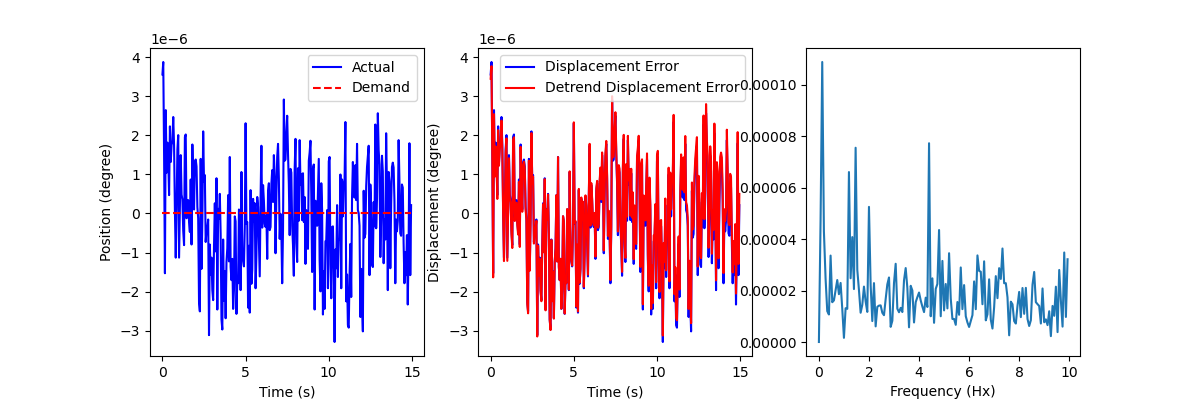

No frequency peak found in the range.


In [31]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=freq_range,
    snr=snr,
    threshold=threshold,
)

### With the TEA Vibration

In [32]:
time_start = Time("2024-03-10T03:00:00", scale="utc", format="isot")
time_end = Time("2024-03-10T03:00:15", scale="utc", format="isot")

is_detrend_data_ok=True


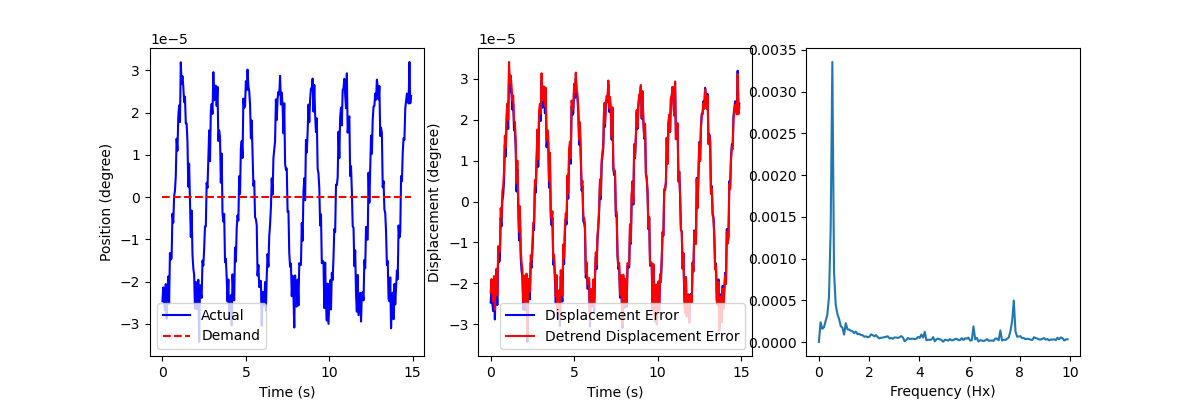

The maximum frequency peak found is 0.54 Hz


In [33]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=freq_range,
    snr=snr,
    threshold=threshold,
)

## Check the Frequencies when the Rotator is Moving

There was the rotator soak test happend at 3/15/2024 that we could use to test the checking of frequencies.

```python
time_start = Time("2024-03-15T21:40:00", scale="utc", format="isot")
time_end = Time("2024-03-15T23:00:00", scale="utc", format="isot")
```

### Rotator is Tracking

In [34]:
time_start = Time("2024-03-15T21:52:30", scale="utc", format="isot")
time_end = Time("2024-03-15T21:52:45", scale="utc", format="isot")

is_detrend_data_ok=True


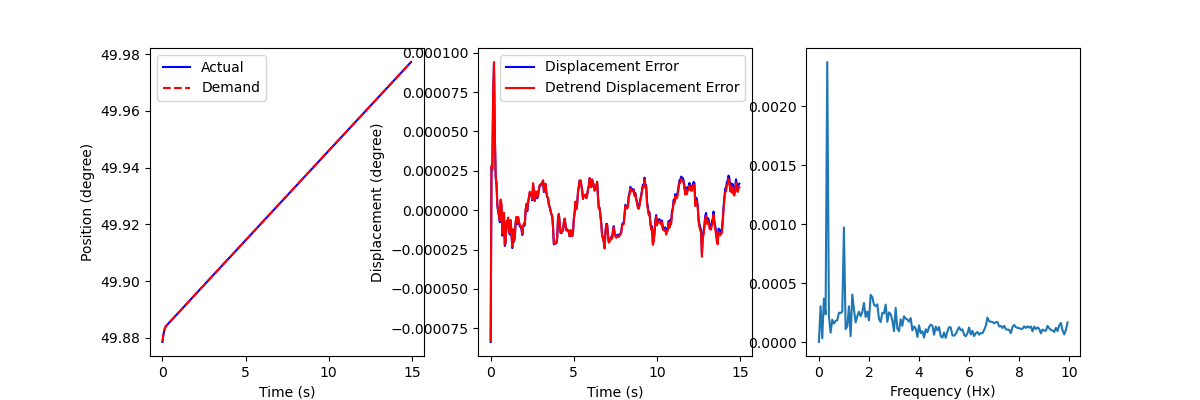

No frequency peak found in the range.


In [35]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=freq_range,
    snr=snr,
    threshold=threshold,
)

In [36]:
time_start = Time("2024-03-15T22:11:16", scale="utc", format="isot")
time_end = Time("2024-03-15T22:11:31", scale="utc", format="isot")

is_detrend_data_ok=True


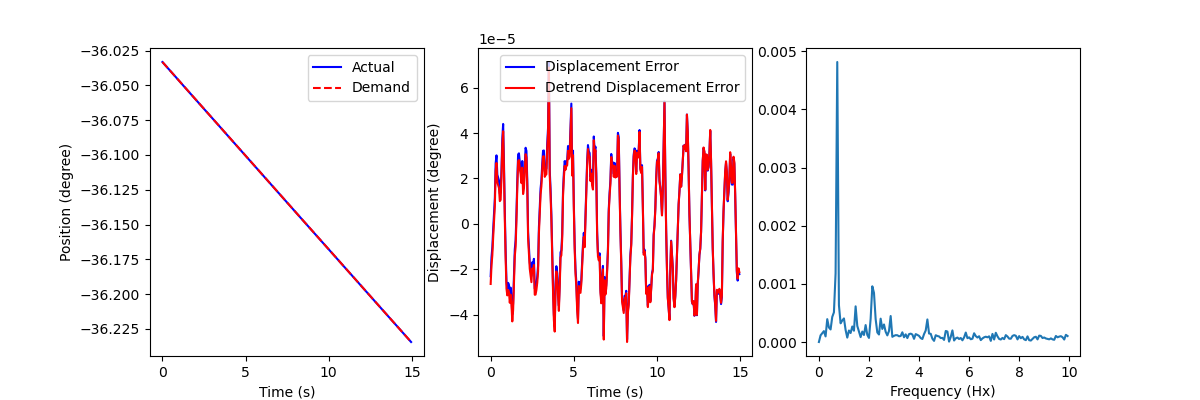

No frequency peak found in the range.


In [37]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=freq_range,
    snr=snr,
    threshold=threshold,
)

In [38]:
time_start = Time("2024-03-15T22:12:00", scale="utc", format="isot")
time_end = Time("2024-03-15T22:12:15", scale="utc", format="isot")

is_detrend_data_ok=True


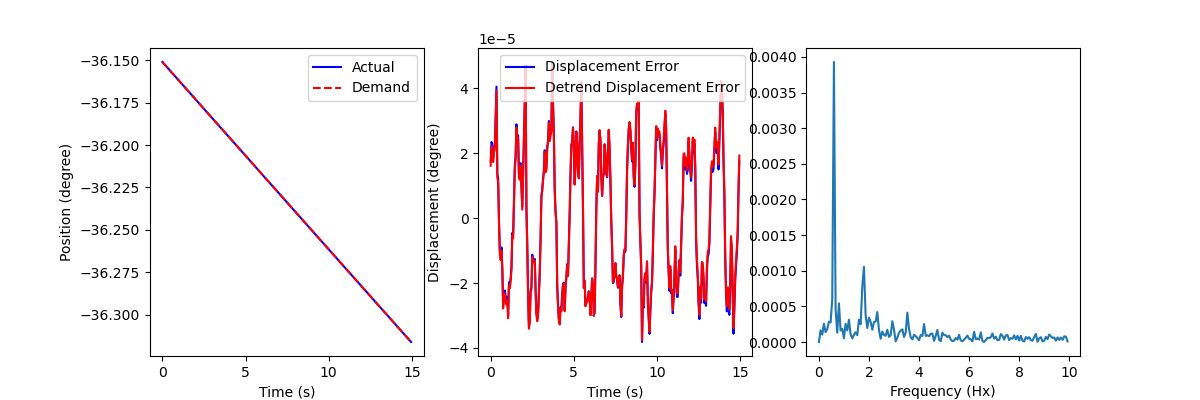

The maximum frequency peak found is 0.60 Hz


In [39]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=freq_range,
    snr=snr,
    threshold=threshold,
)

In [40]:
time_start = Time("2024-03-15T22:15:58", scale="utc", format="isot")
time_end = Time("2024-03-15T22:16:13", scale="utc", format="isot")

is_detrend_data_ok=True


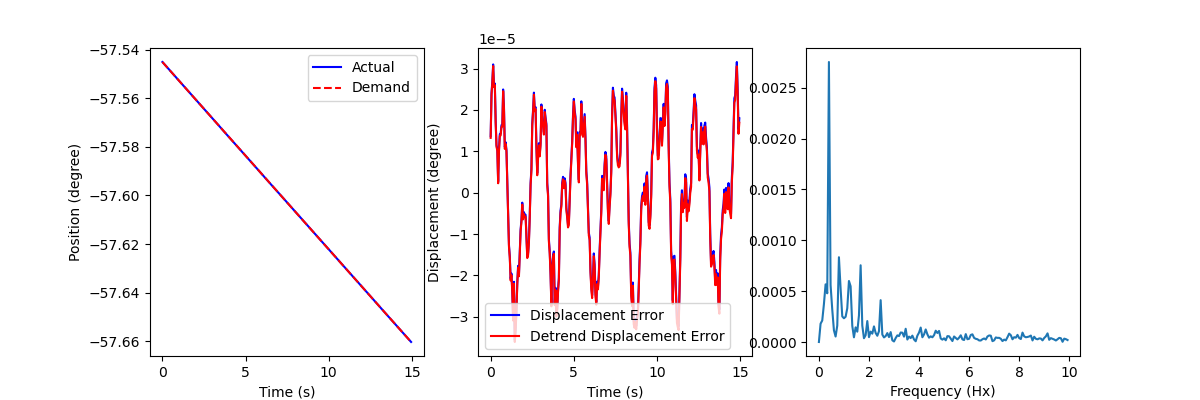

The maximum frequency peak found is 0.40 Hz


In [41]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=freq_range,
    snr=snr,
    threshold=threshold,
)

### Rotator is Slewing

In [42]:
time_start = Time("2024-03-15T21:56:31", scale="utc", format="isot")
time_end = Time("2024-03-15T21:56:46", scale="utc", format="isot")

is_detrend_data_ok=True


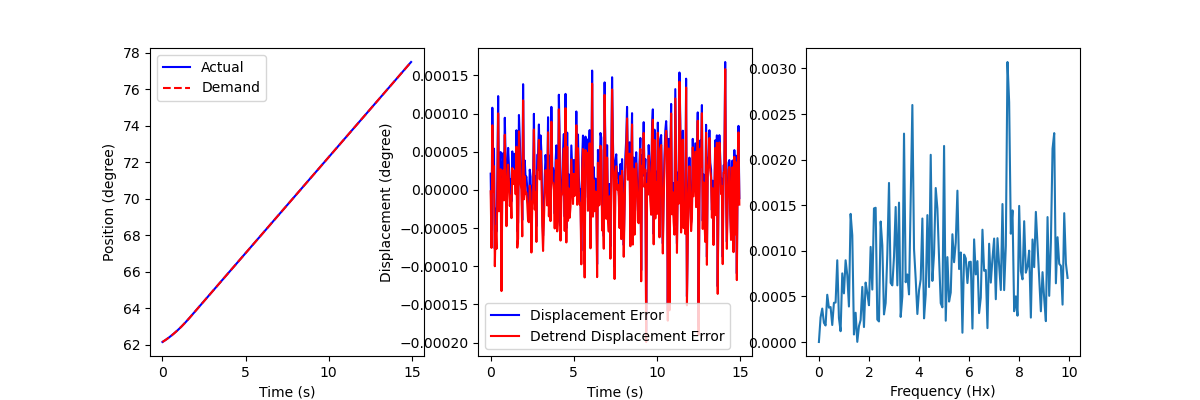

No frequency peak found in the range.


In [43]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=freq_range,
    snr=snr,
    threshold=threshold,
)

In [44]:
time_start = Time("2024-03-15T22:00:32", scale="utc", format="isot")
time_end = Time("2024-03-15T22:00:47", scale="utc", format="isot")

is_detrend_data_ok=True


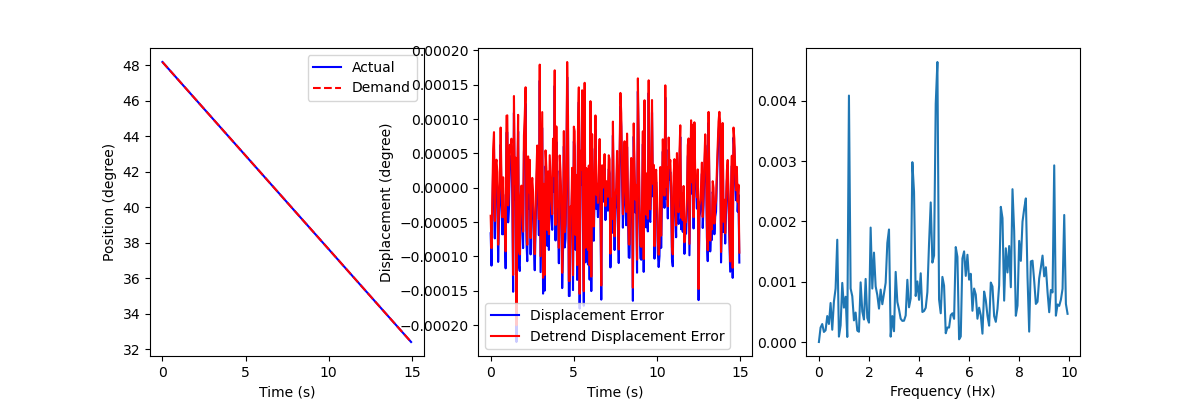

No frequency peak found in the range.


In [45]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=freq_range,
    snr=snr,
    threshold=threshold,
)

### Rotator Transitions between Slewing and Tracking

In [46]:
time_start = Time("2024-03-15T21:56:45", scale="utc", format="isot")
time_end = Time("2024-03-15T21:57:00", scale="utc", format="isot")

is_detrend_data_ok=True


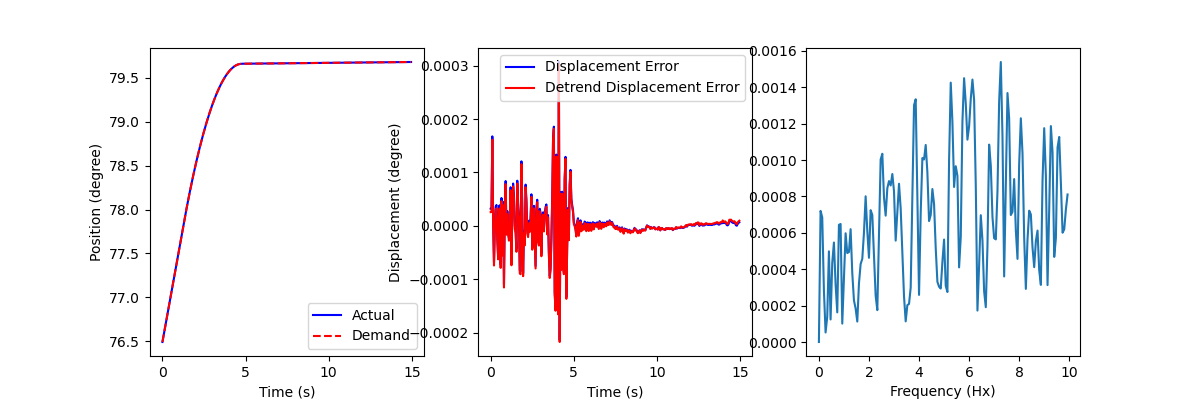

No frequency peak found in the range.


In [47]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=(0.4, 0.8),
    snr=10,
    threshold=1e-3,
)

In [48]:
time_start = Time("2024-03-15T22:16:10", scale="utc", format="isot")
time_end = Time("2024-03-15T22:16:25", scale="utc", format="isot")

is_detrend_data_ok=False


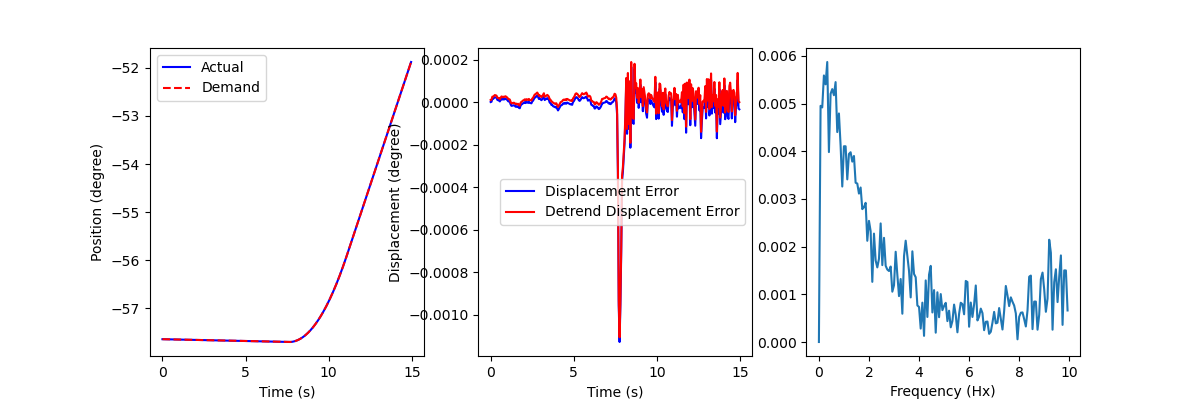

No frequency peak found in the range.


In [49]:
data = await get_efd_data(efd_client, time_start, time_end)

plot_position_and_frequency(
    data,
    freq_range=(0.4, 0.8),
    snr=10,
    threshold=1e-3,
)

In [29]:
plt.close("all")